# ACE vs EXFOR Angular Distribution (Energy-Folded)

In [1]:
# --- EXFOR config ---
EXFOR_DB_PATH = '/share_snc/snc/JuanMonleon/EXFOR/x4_iron_angular.db'
TARGET = "Fe56"
TARGET_NAT = "Fe"
MT = 2
TARGET_ENERGY = 1.31       # MeV
ENERGY_TOLERANCE = 0.02      # MeV

# --- Energy folding (TOF) ---
FLIGHT_PATH_M = 27.037       # meters
DELTA_T_NS = 5.0             # nanoseconds
ENERGY_FOLDING = True

# --- ACE files dict: label -> {path, color, linestyle} ---
ACE_FILES = {
    'ENDF/B-VIII.0': {
        'path': '/mnt/c/Users/MONLEON-DE-LA-JAN/Documents/ACE_samples/260560_81.02c',
        'color': 'black',
        'linestyle': '-',
    },
    'JEFF-4.0': {
        'path': '/mnt/c/Users/MONLEON-DE-LA-JAN/Documents/ACE_samples/260560_40.02c',
        'color': 'red',
        'linestyle': '--',
    },
}

# --- Sample ACE files (plotted in light grey, one shared label) ---
SAMPLE_FILES = [
    '/mnt/c/Users/MONLEON-DE-LA-JAN/Documents/ACE_samples/260560_31.02c',
    '/mnt/c/Users/MONLEON-DE-LA-JAN/Documents/ACE_samples/26056.20c',
    # '/path/to/sample2.ace',
]

In [2]:
import kika
import kika.exfor as exfor
from kika.exfor import read_all_exfor
from kika.plotting import PlotBuilder
import matplotlib.pyplot as plt
import numpy as np

# Configure EXFOR database
exfor.configure(db_path=EXFOR_DB_PATH)

# ── Load ACE files ──────────────────────────────────────────────────────────
ace_plot_data_list = []
for label, cfg in ACE_FILES.items():
    ace = kika.read_ace(cfg['path'])
    pd = ace.angular_distributions.to_plot_data(
        mt=MT,
        energy=TARGET_ENERGY,
        ace=ace,
        energy_folding=ENERGY_FOLDING,
        tof=(FLIGHT_PATH_M, DELTA_T_NS),
        normalize_to_xs=True,
        cross_section_unit='b/sr',
        interpolate=True,
        num_points=200,
        label=label,
        color=cfg.get('color', None),
        linestyle=cfg.get('linestyle', '-'),
        linewidth=2,
    )
    ace_plot_data_list.append(pd)

# ── Load sample ACE files ───────────────────────────────────────────────────
sample_plot_data_list = []
for i, spath in enumerate(SAMPLE_FILES):
    sace = kika.read_ace(spath)
    spd = sace.angular_distributions.to_plot_data(
        mt=MT,
        energy=TARGET_ENERGY,
        ace=sace,
        energy_folding=ENERGY_FOLDING,
        tof=(FLIGHT_PATH_M, DELTA_T_NS),
        normalize_to_xs=True,
        cross_section_unit='b/sr',
        interpolate=True,
        num_points=200,
        label='Samples' if i == 0 else '_nolegend_',
        color='grey',
        linewidth=1,
        alpha=0.5,
    )
    sample_plot_data_list.append(spd)



In [3]:
# ── Load EXFOR experiments ──────────────────────────────────────────────────
fe56_experiments = read_all_exfor(target=TARGET, mt=MT, group_by_energy=False)
fe_nat_experiments = read_all_exfor(target=TARGET_NAT, mt=MT, group_by_energy=False)

fe56_near = []
for exp_id, exp in fe56_experiments.items():
    energies = exp.energies(unit='MeV')
    if np.any(np.abs(energies - TARGET_ENERGY) <= ENERGY_TOLERANCE):
        fe56_near.append(exp)

fe_nat_near = []
for exp_id, exp in fe_nat_experiments.items():
    energies = exp.energies(unit='MeV')
    if np.any(np.abs(energies - TARGET_ENERGY) <= ENERGY_TOLERANCE):
        fe_nat_near.append(exp)

all_experiments = fe56_near + fe_nat_near
print(f'EXFOR matches near {TARGET_ENERGY} MeV: {len(fe56_near)} ({TARGET}) + {len(fe_nat_near)} ({TARGET_NAT}-nat)')

EXFOR matches near 1.31 MeV: 1 (Fe56) + 3 (Fe-nat)


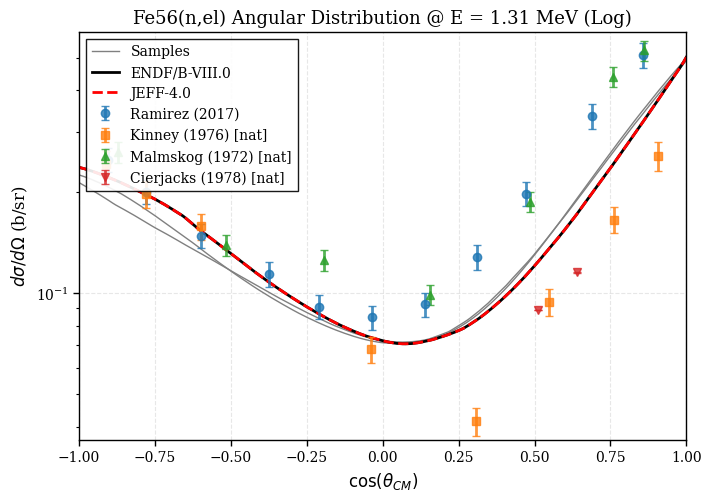

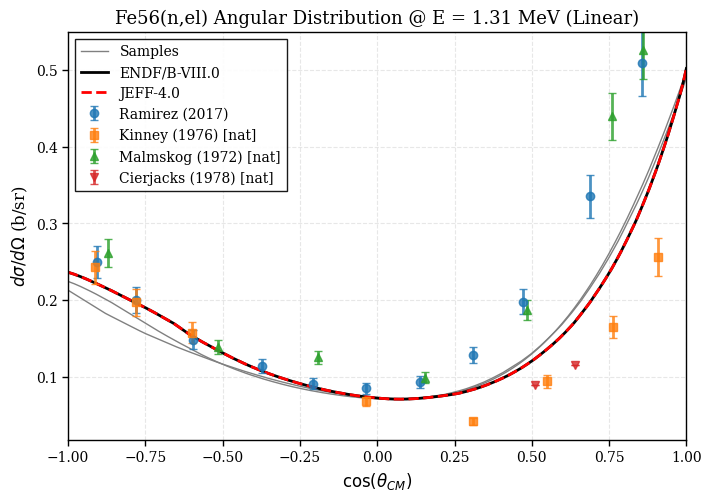

In [4]:
# ── Build plots ─────────────────────────────────────────────────────────────
markers = ['o', 's', '^', 'v', 'D', 'p', 'h', '*']
colors = plt.cm.tab10.colors

for log_y in [True, False]:
    builder = PlotBuilder(figsize=(10, 7))

    # Add sample curves first (behind everything)
    for spd in sample_plot_data_list:
        builder.add_data(spd)

    # Add ACE evaluated curves
    for apd in ace_plot_data_list:
        builder.add_data(apd)

    # Add EXFOR experiments
    plotted_count = 0
    for exp in all_experiments:
        plot_data = exp.to_plot_data(
            energy=TARGET_ENERGY,
            tolerance=ENERGY_TOLERANCE,
            frame='CM',
            angle_unit='cos',
            cross_section_unit='b/sr',
            uncertainty=True,
            include_natural_tag=True,
            marker=markers[plotted_count % len(markers)],
            color=colors[plotted_count % len(colors)],
            markersize=6,
            capsize=3,
            alpha=0.8,
        )
        if plot_data is not None:
            builder.add_data(plot_data)
            plotted_count += 1

    scale_label = 'Log' if log_y else 'Linear'
    fig = (builder
           .set_labels(
               title=f"{TARGET}(n,el) Angular Distribution @ E = {TARGET_ENERGY} MeV ({scale_label})",
               x_label=r"$\cos(\theta_{CM})$",
               y_label=r"$d\sigma/d\Omega$ (b/sr)",
           )
           .set_scales(log_y=log_y)
           .set_legend(loc='upper left')
           .build())

    plt.show()